In [9]:
!pip install duckdb
#installing duckdb, which is lightweight, fast analytical database. allows for high-speed in memory, processing, works with standard SQL, and is easy to use since it operates as a singlefile


In [17]:
# ══════════════════════════════════════════════════════
# STEP 1: Import libraries and load the data
# ══════════════════════════════════════════════════════
import pandas as pd
import duckdb

pd.set_option("display.max_columns", None)   # show all columns, no truncation
pd.set_option("display.width", 120)          # wider display so rows don't wrap awkwardly

df = pd.read_csv("gaming_data_export.csv")

print("="*60)
print("STEP 1: DATA LOADED")
print("="*60)
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
print(f"Columns: {', '.join(df.columns)}")


# ══════════════════════════════════════════════════════
# STEP 2: Register as SQL table
# ══════════════════════════════════════════════════════
con = duckdb.connect()
con.register("raw_data", df)

total_rows = con.execute("SELECT COUNT(*) FROM raw_data").fetchone()[0]
print("\n" + "="*60)
print("STEP 2: SQL TABLE REGISTERED")
print("="*60)
print(f"Confirmed {total_rows:,} rows accessible via SQL")


# ══════════════════════════════════════════════════════
# STEP 3: Check for missing (NULL) values
# ══════════════════════════════════════════════════════
null_check = con.execute("""
    SELECT
        SUM(CASE WHEN Date IS NULL THEN 1 ELSE 0 END)                          AS "Date",
        SUM(CASE WHEN Platform IS NULL THEN 1 ELSE 0 END)                      AS "Platform",
        SUM(CASE WHEN "Daily Active Users (DAU)" IS NULL THEN 1 ELSE 0 END)    AS "DAU",
        SUM(CASE WHEN "New Registrations" IS NULL THEN 1 ELSE 0 END)          AS "New Registrations",
        SUM(CASE WHEN "Session Duration (minutes)" IS NULL THEN 1 ELSE 0 END) AS "Session Duration",
        SUM(CASE WHEN "In-game Purchases ($)" IS NULL THEN 1 ELSE 0 END)      AS "In-game Purchases",
        SUM(CASE WHEN "Social Media Mentions" IS NULL THEN 1 ELSE 0 END)      AS "Social Mentions",
        SUM(CASE WHEN "Stream Viewership" IS NULL THEN 1 ELSE 0 END)          AS "Stream Viewership",
        SUM(CASE WHEN "Revenue ($)" IS NULL THEN 1 ELSE 0 END)                AS "Revenue",
        SUM(CASE WHEN "Top Genre" IS NULL THEN 1 ELSE 0 END)                  AS "Top Genre",
        SUM(CASE WHEN "Influencer Endorsements" IS NULL THEN 1 ELSE 0 END)    AS "Influencer Endorsements"
    FROM raw_data
""").fetchdf()

print("\n" + "="*60)
print("STEP 3: NULL VALUE CHECK")
print("="*60)
null_counts = null_check.iloc[0]
any_nulls = False
for col, count in null_counts.items():
    if count > 0:
        print(f"  ⚠️  {col}: {count} missing")
        any_nulls = True
if not any_nulls:
    print("  ✅ No missing values in any column")


# ══════════════════════════════════════════════════════
# STEP 4: Check for duplicate rows
# ══════════════════════════════════════════════════════
duplicates = con.execute("""
    SELECT Date, Platform, COUNT(*) AS occurrences
    FROM raw_data
    GROUP BY Date, Platform
    HAVING COUNT(*) > 1
""").fetchdf()

print("\n" + "="*60)
print("STEP 4: DUPLICATE CHECK")
print("="*60)
if len(duplicates) == 0:
    print("  ✅ No duplicate Date+Platform combinations found")
else:
    print(f"  ⚠️  {len(duplicates)} duplicate combinations found:")
    print(duplicates.to_string(index=False))


# ══════════════════════════════════════════════════════
# STEP 5: Check for invalid negative values
# ══════════════════════════════════════════════════════
invalid_values = con.execute("""
    SELECT *
    FROM raw_data
    WHERE "Daily Active Users (DAU)" < 0
       OR "New Registrations" < 0
       OR "Session Duration (minutes)" < 0
       OR "In-game Purchases ($)" < 0
       OR "Social Media Mentions" < 0
       OR "Stream Viewership" < 0
       OR "Revenue ($)" < 0
       OR "Influencer Endorsements" < 0
""").fetchdf()

print("\n" + "="*60)
print("STEP 5: NEGATIVE VALUE CHECK")
print("="*60)
if len(invalid_values) == 0:
    print("  ✅ No negative values found in any numeric column")
else:
    print(f"  ⚠️  {len(invalid_values)} rows with negative values found")


# ══════════════════════════════════════════════════════
# STEP 6: Check categorical columns
# ══════════════════════════════════════════════════════
platforms = con.execute('SELECT DISTINCT Platform FROM raw_data ORDER BY Platform').fetchdf()["Platform"].tolist()
genres = con.execute('SELECT DISTINCT "Top Genre" FROM raw_data ORDER BY "Top Genre"').fetchdf()["Top Genre"].tolist()

print("\n" + "="*60)
print("STEP 6: CATEGORY CHECK")
print("="*60)
print(f"  Platforms ({len(platforms)}): {', '.join(platforms)}")
print(f"  Genres ({len(genres)}):    {', '.join(genres)}")


# ══════════════════════════════════════════════════════
# STEP 7: Check date range
# ══════════════════════════════════════════════════════
date_check = con.execute("""
    SELECT MIN(Date) AS earliest, MAX(Date) AS latest, COUNT(DISTINCT Date) AS unique_dates
    FROM raw_data
""").fetchdf().iloc[0]

print("\n" + "="*60)
print("STEP 7: DATE RANGE CHECK")
print("="*60)
print(f"  Earliest date:  {date_check['earliest']}")
print(f"  Latest date:    {date_check['latest']}")
print(f"  Unique dates:   {date_check['unique_dates']:,}")


# ══════════════════════════════════════════════════════
# STEP 8: Check for outliers in Revenue
# ══════════════════════════════════════════════════════
outliers = con.execute("""
    SELECT *
    FROM raw_data
    WHERE "Revenue ($)" > (SELECT AVG("Revenue ($)") + 3 * STDDEV("Revenue ($)") FROM raw_data)
       OR "Revenue ($)" < (SELECT AVG("Revenue ($)") - 3 * STDDEV("Revenue ($)") FROM raw_data)
""").fetchdf()

print("\n" + "="*60)
print("STEP 8: REVENUE OUTLIER CHECK")
print("="*60)
if len(outliers) == 0:
    print("  ✅ No extreme outliers detected (beyond 3 standard deviations)")
else:
    print(f"  ⚠️  {len(outliers)} potential outlier rows found")


# ══════════════════════════════════════════════════════
# STEP 9: Clean the data
# ══════════════════════════════════════════════════════
clean_data = con.execute("""
    SELECT DISTINCT *
    FROM raw_data
    WHERE "Daily Active Users (DAU)" >= 0
      AND "Session Duration (minutes)" >= 0
      AND "In-game Purchases ($)" >= 0
      AND "Revenue ($)" >= 0
    ORDER BY Date
""").fetchdf()

print("\n" + "="*60)
print("STEP 9: CLEANING SUMMARY")
print("="*60)
print(f"  Rows before cleaning: {len(df):,}")
print(f"  Rows after cleaning:  {len(clean_data):,}")
print(f"  Rows removed:         {len(df) - len(clean_data):,}")


# ══════════════════════════════════════════════════════
# STEP 10: Final readiness check
# ══════════════════════════════════════════════════════
con.register("clean_data", clean_data)

final_check = con.execute("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT Date) AS unique_dates,
        MIN(Date) AS earliest_date,
        MAX(Date) AS latest_date,
        SUM(CASE WHEN "Revenue ($)" IS NULL THEN 1 ELSE 0 END) AS remaining_nulls
    FROM clean_data
""").fetchdf().iloc[0]

print("\n" + "="*60)
print("STEP 10: FINAL READINESS CHECK")
print("="*60)
print(f"  Total rows:      {final_check['total_rows']:,}")
print(f"  Date range:      {final_check['earliest_date']} → {final_check['latest_date']}")
print(f"  Unique dates:    {final_check['unique_dates']:,}")
print(f"  Remaining nulls: {final_check['remaining_nulls']}")

print("\n" + "="*60)
if final_check["remaining_nulls"] == 0:
    print("✅ DATA CLEANING COMPLETE — READY FOR ANALYSIS")
else:
    print("⚠️  ISSUES REMAIN — REVIEW BEFORE ANALYSIS")
print("="*60)


# ══════════════════════════════════════════════════════
# STEP 11: Save the cleaned data
# ══════════════════════════════════════════════════════
clean_data.to_csv("gaming_data_cleaned.csv", index=False)
print(f"\n📁 Saved cleaned data to gaming_data_cleaned.csv ({len(clean_data):,} rows)")


STEP 1: DATA LOADED
Rows: 4,989   Columns: 11
Columns: Date, Platform, Daily Active Users (DAU), New Registrations, Session Duration (minutes), In-game Purchases ($), Social Media Mentions, Stream Viewership, Revenue ($), Top Genre, Influencer Endorsements

STEP 2: SQL TABLE REGISTERED
Confirmed 4,989 rows accessible via SQL

STEP 3: NULL VALUE CHECK
  ✅ No missing values in any column

STEP 4: DUPLICATE CHECK
  ⚠️  97 duplicate combinations found:
      Date Platform  occurrences
2020-01-30       VR            2
2020-06-11  Console            2
2020-01-02       VR            2
2020-10-25       PC            2
2020-08-26       PC            2
2019-07-18  Console            2
2019-07-01       PC            2
2020-04-26       VR            2
2019-05-21       PC            2
2020-08-12   Mobile            2
2018-07-10   Mobile            2
2019-09-22       PC            2
2019-03-16  Console            2
2018-01-12       VR            2
2020-03-23       VR            2
2020-10-27  Console

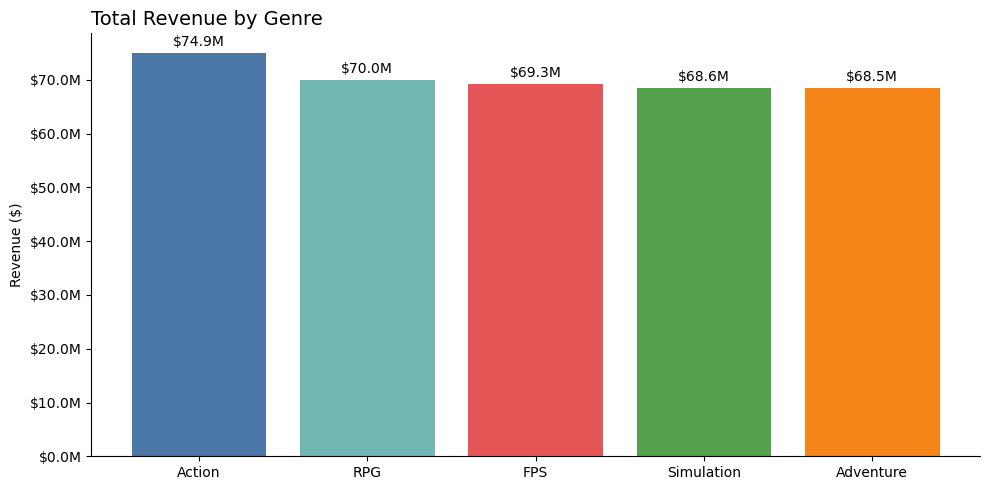

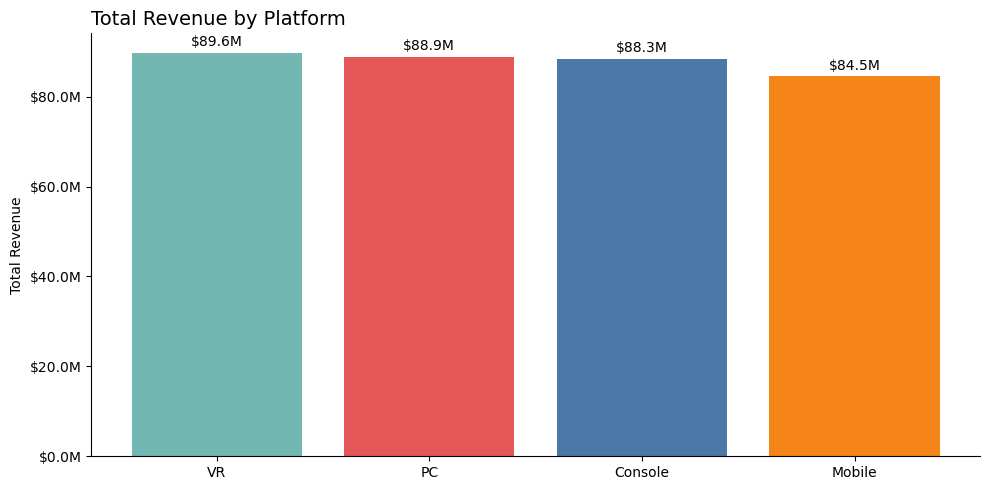

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Load your cleaned data
df = pd.read_csv("gaming_data_cleaned.csv")

# ── Color palette (matching Tableau's default colors) ──
COLORS = {
    'Action': '#4C78A8', 'RPG': '#72B7B2', 'FPS': '#E45756',
    'Simulation': '#54A24B', 'Adventure': '#F58518',
    'Console': '#4C78A8', 'Mobile': '#F58518', 'PC': '#E45756', 'VR': '#72B7B2'
}

# ── Chart 1: Total Revenue by Genre ─────────────────────
genre_revenue = df.groupby("Top Genre")["Revenue ($)"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(genre_revenue.index, genre_revenue.values,
               color=[COLORS.get(g, '#999999') for g in genre_revenue.index])

# Add value labels on top of each bar
for bar, value in zip(bars, genre_revenue.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + value*0.01,
            f"${value/1e6:.1f}M", ha='center', va='bottom', fontsize=10)

ax.set_title("Total Revenue by Genre", fontsize=14, loc='left')
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("revenue_by_genre.png", dpi=150)
plt.show()

# ── Chart 2: Total Revenue by Platform ──────────────────
platform_revenue = df.groupby("Platform")["Revenue ($)"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(platform_revenue.index, platform_revenue.values,
               color=[COLORS.get(p, '#999999') for p in platform_revenue.index])

for bar, value in zip(bars, platform_revenue.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + value*0.01,
            f"${value/1e6:.1f}M", ha='center', va='bottom', fontsize=10)

ax.set_title("Total Revenue by Platform", fontsize=14, loc='left')
ax.set_ylabel("Total Revenue")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("revenue_by_platform.png", dpi=150)
plt.show()

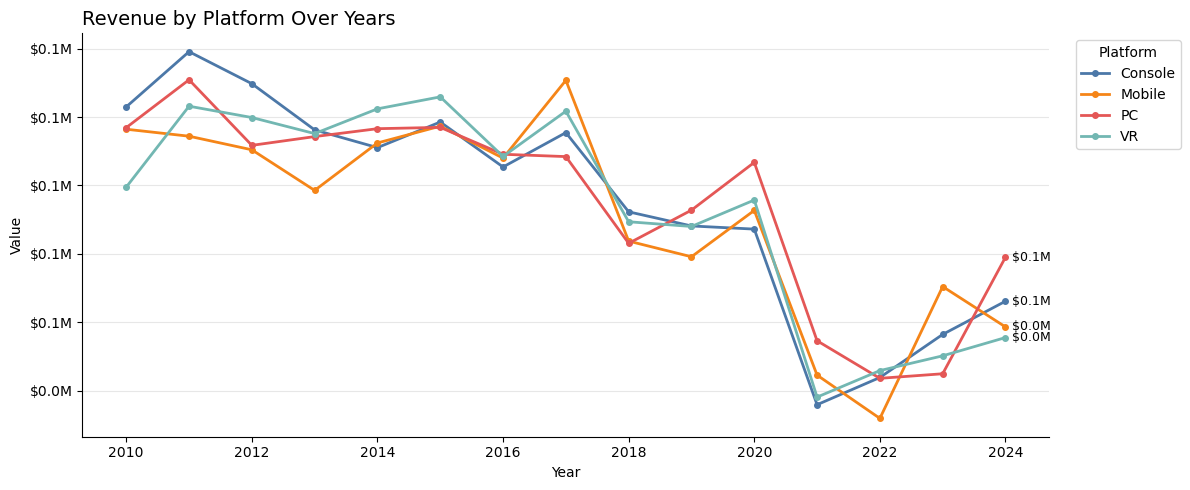

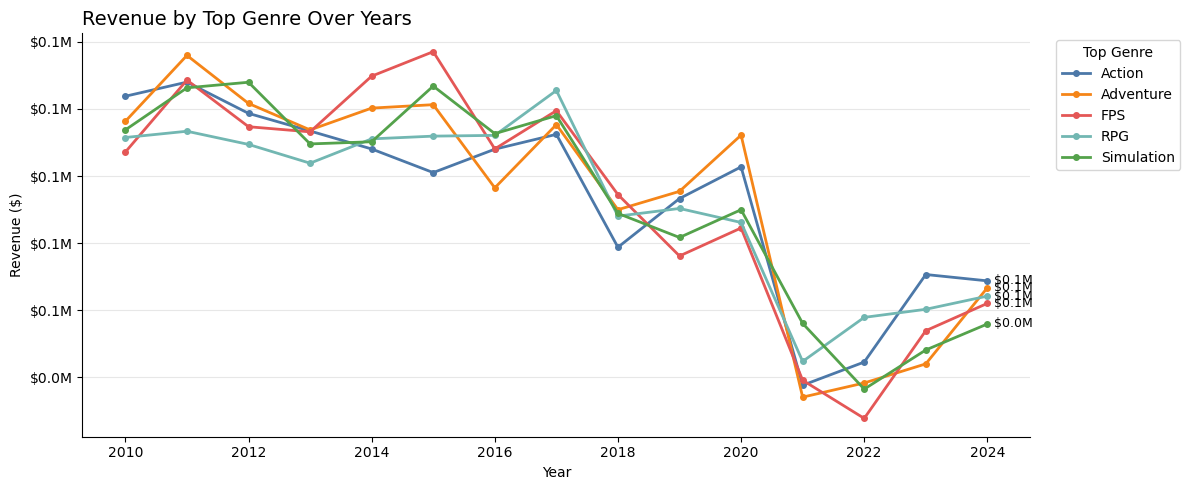

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Load your cleaned data
df = pd.read_csv("gaming_data_cleaned.csv")

# Extract Year from the Date column
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year

# ── Color palette (consistent with earlier charts) ──
PLATFORM_COLORS = {'Console': '#4C78A8', 'Mobile': '#F58518', 'PC': '#E45756', 'VR': '#72B7B2'}
GENRE_COLORS = {'Action': '#4C78A8', 'Adventure': '#F58518', 'FPS': '#E45756',
                'RPG': '#72B7B2', 'Simulation': '#54A24B'}

# ── Chart 1: Revenue by Platform Over Years ─────────────
platform_yearly = df.groupby(["Year", "Platform"])["Revenue ($)"].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 5))
for platform in platform_yearly.columns:
    ax.plot(platform_yearly.index, platform_yearly[platform],
            label=platform, color=PLATFORM_COLORS.get(platform, '#999999'),
            linewidth=2, marker='o', markersize=4)

# Label the last point on each line
for platform in platform_yearly.columns:
    last_year = platform_yearly.index[-1]
    last_value = platform_yearly[platform].iloc[-1]
    ax.annotate(f"${last_value/1e6:.1f}M", (last_year, last_value),
                xytext=(5, 0), textcoords='offset points', fontsize=9, va='center')

ax.set_title("Revenue by Platform Over Years", fontsize=14, loc='left')
ax.set_xlabel("Year")
ax.set_ylabel("Value")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.legend(title="Platform", loc='upper left', bbox_to_anchor=(1.02, 1))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("revenue_by_platform_over_years.png", dpi=150)
plt.show()

# ── Chart 2: Revenue by Top Genre Over Years ────────────
genre_yearly = df.groupby(["Year", "Top Genre"])["Revenue ($)"].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 5))
for genre in genre_yearly.columns:
    ax.plot(genre_yearly.index, genre_yearly[genre],
            label=genre, color=GENRE_COLORS.get(genre, '#999999'),
            linewidth=2, marker='o', markersize=4)

for genre in genre_yearly.columns:
    last_year = genre_yearly.index[-1]
    last_value = genre_yearly[genre].iloc[-1]
    ax.annotate(f"${last_value/1e6:.1f}M", (last_year, last_value),
                xytext=(5, 0), textcoords='offset points', fontsize=9, va='center')

ax.set_title("Revenue by Top Genre Over Years", fontsize=14, loc='left')
ax.set_xlabel("Year")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.legend(title="Top Genre", loc='upper left', bbox_to_anchor=(1.02, 1))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("revenue_by_genre_over_years.png", dpi=150)
plt.show()

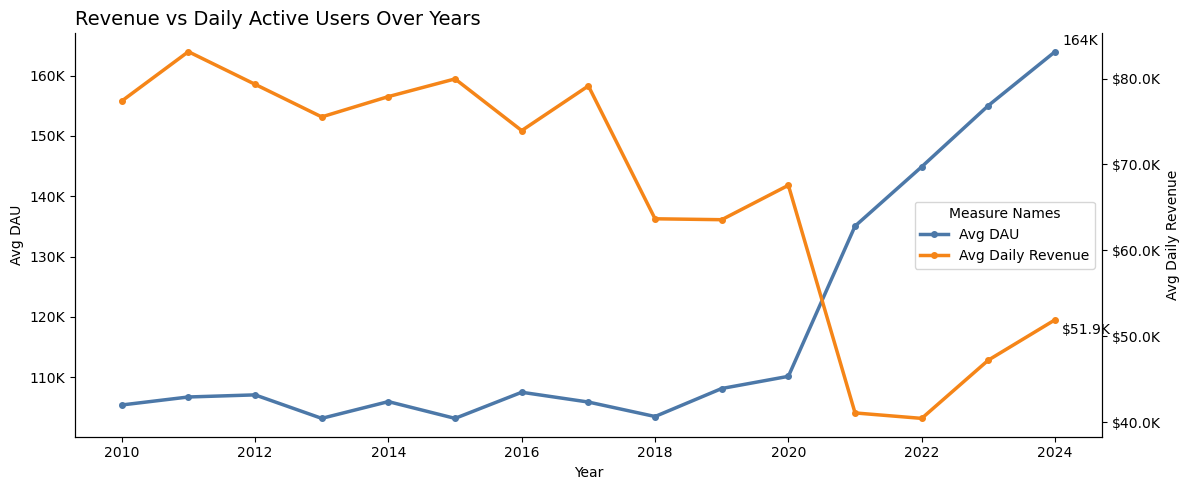

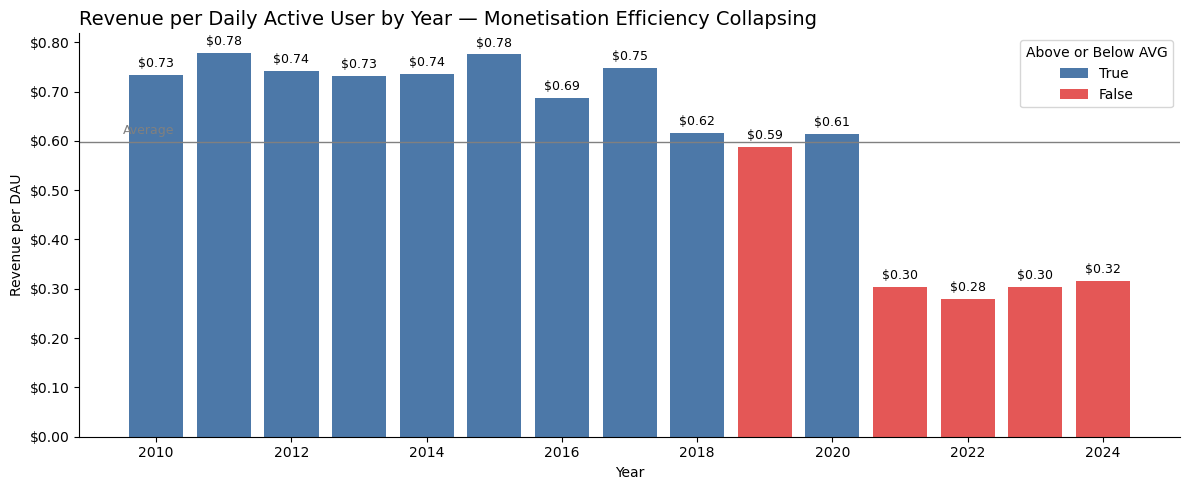

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Load your cleaned data
df = pd.read_csv("gaming_data_cleaned.csv")
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year

# Aggregate yearly averages
yearly = df.groupby("Year").agg(
    Avg_DAU=("Daily Active Users (DAU)", "mean"),
    Avg_Revenue=("Revenue ($)", "mean")
).reset_index()

# ── Chart 1: Revenue vs Daily Active Users Over Years (dual-axis) ──
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(yearly["Year"], yearly["Avg_DAU"], color='#4C78A8',
         linewidth=2.5, marker='o', markersize=4, label='Avg DAU')
ax2.plot(yearly["Year"], yearly["Avg_Revenue"], color='#F58518',
         linewidth=2.5, marker='o', markersize=4, label='Avg Daily Revenue')

# Label endpoints
last_dau = yearly["Avg_DAU"].iloc[-1]
last_year = yearly["Year"].iloc[-1]
last_rev = yearly["Avg_Revenue"].iloc[-1]
ax1.annotate(f"{last_dau/1e3:.0f}K", (last_year, last_dau),
             xytext=(5, 5), textcoords='offset points', fontsize=10)
ax2.annotate(f"${last_rev/1e3:.1f}K", (last_year, last_rev),
             xytext=(5, -10), textcoords='offset points', fontsize=10)

ax1.set_title("Revenue vs Daily Active Users Over Years", fontsize=14, loc='left')
ax1.set_xlabel("Year")
ax1.set_ylabel("Avg DAU")
ax2.set_ylabel("Avg Daily Revenue")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.1f}K"))

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', title="Measure Names")

ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)
plt.tight_layout()
plt.savefig("revenue_vs_dau_over_years.png", dpi=150)
plt.show()

# ── Chart 2: Revenue per Daily Active User by Year ──────
yearly["Revenue_per_DAU"] = yearly["Avg_Revenue"] / yearly["Avg_DAU"]
overall_avg = yearly["Revenue_per_DAU"].mean()

# Color bars based on above/below average
colors = ['#4C78A8' if v >= overall_avg else '#E45756' for v in yearly["Revenue_per_DAU"]]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(yearly["Year"], yearly["Revenue_per_DAU"], color=colors)

# Value labels on top of bars
for bar, value in zip(bars, yearly["Revenue_per_DAU"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"${value:.2f}", ha='center', va='bottom', fontsize=9)

# Average reference line
ax.axhline(overall_avg, color='gray', linewidth=1)
ax.text(yearly["Year"].iloc[0] - 0.5, overall_avg + 0.01, "Average",
        fontsize=9, color='gray', va='bottom')

ax.set_title("Revenue per Daily Active User by Year — Monetisation Efficiency Collapsing",
             fontsize=14, loc='left')
ax.set_xlabel("Year")
ax.set_ylabel("Revenue per DAU")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.2f}"))
ax.spines[['top', 'right']].set_visible(False)

# Custom legend for above/below average
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4C78A8', label='True'),
                    Patch(facecolor='#E45756', label='False')]
ax.legend(handles=legend_elements, title="Above or Below AVG", loc='upper right')

plt.tight_layout()
plt.savefig("revenue_per_dau_by_year.png", dpi=150)
plt.show()

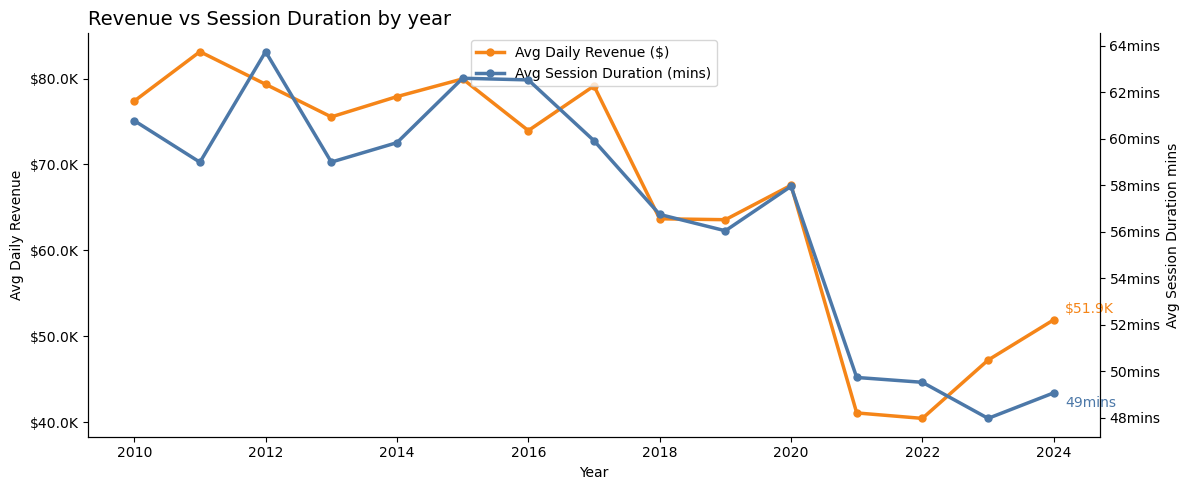

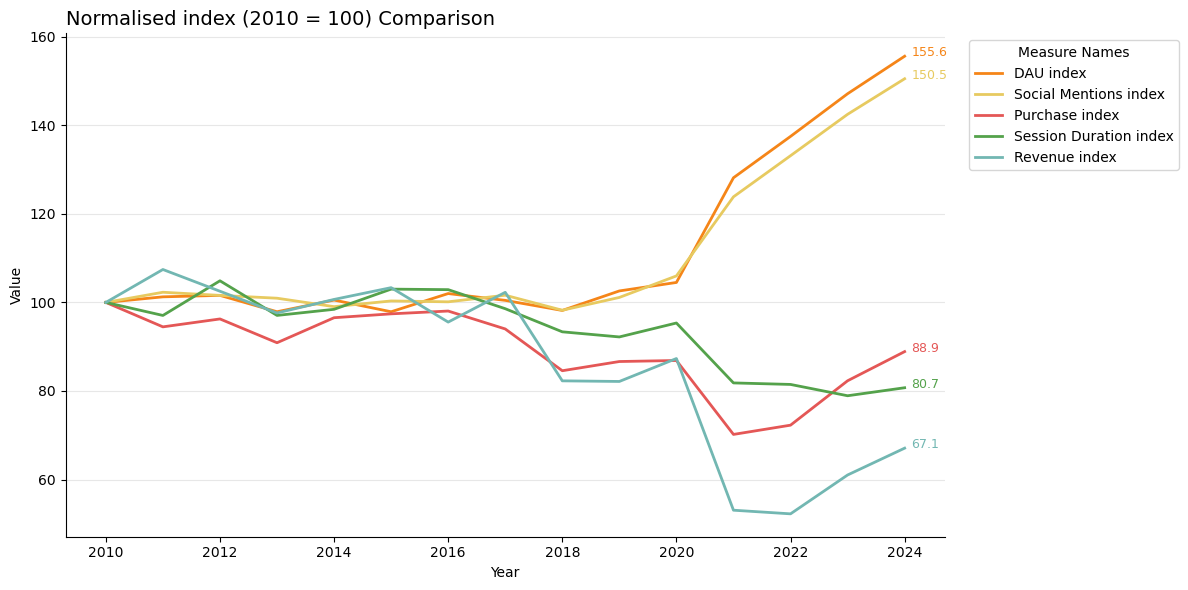

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Load your cleaned data
df = pd.read_csv("gaming_data_cleaned.csv")
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year

# Aggregate yearly averages for all measures we need
yearly = df.groupby("Year").agg(
    Revenue=("Revenue ($)", "mean"),
    DAU=("Daily Active Users (DAU)", "mean"),
    Session_Duration=("Session Duration (minutes)", "mean"),
    Purchases=("In-game Purchases ($)", "mean"),
    Social_Mentions=("Social Media Mentions", "mean")
).reset_index()

# ── Chart 1: Revenue vs Session Duration by Year (dual-axis) ──
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(yearly["Year"], yearly["Revenue"], color='#F58518',
         linewidth=2.5, marker='o', markersize=5, label='Avg Daily Revenue ($)')
ax2.plot(yearly["Year"], yearly["Session_Duration"], color='#4C78A8',
         linewidth=2.5, marker='o', markersize=5, label='Avg Session Duration (mins)')

# Label endpoints
last_year = yearly["Year"].iloc[-1]
last_rev = yearly["Revenue"].iloc[-1]
last_sess = yearly["Session_Duration"].iloc[-1]
ax1.annotate(f"${last_rev/1e3:.1f}K", (last_year, last_rev),
             xytext=(8, 5), textcoords='offset points', fontsize=10, color='#F58518')
ax2.annotate(f"{last_sess:.0f}mins", (last_year, last_sess),
             xytext=(8, -10), textcoords='offset points', fontsize=10, color='#4C78A8')

ax1.set_title("Revenue vs Session Duration by year", fontsize=14, loc='left')
ax1.set_xlabel("Year")
ax1.set_ylabel("Avg Daily Revenue")
ax2.set_ylabel("Avg Session Duration mins")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.1f}K"))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}mins"))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center')

ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)
plt.tight_layout()
plt.savefig("revenue_vs_session_duration.png", dpi=150)
plt.show()

# ── Chart 2: Normalised Index (2010 = 100) Comparison ───
# Normalize each metric so 2010 = 100, showing relative % change over time
base_year = yearly[yearly["Year"] == yearly["Year"].min()].iloc[0]

norm = pd.DataFrame({"Year": yearly["Year"]})
norm["DAU index"] = yearly["DAU"] / base_year["DAU"] * 100
norm["Social Mentions index"] = yearly["Social_Mentions"] / base_year["Social_Mentions"] * 100
norm["Purchase index"] = yearly["Purchases"] / base_year["Purchases"] * 100
norm["Session Duration index"] = yearly["Session_Duration"] / base_year["Session_Duration"] * 100
norm["Revenue index"] = yearly["Revenue"] / base_year["Revenue"] * 100

INDEX_COLORS = {
    "DAU index": "#F58518",
    "Social Mentions index": "#E7CA60",
    "Purchase index": "#E45756",
    "Session Duration index": "#54A24B",
    "Revenue index": "#72B7B2"
}

fig, ax = plt.subplots(figsize=(12, 6))
for col, color in INDEX_COLORS.items():
    ax.plot(norm["Year"], norm[col], label=col, color=color, linewidth=2)
    # Label the last point
    last_val = norm[col].iloc[-1]
    ax.annotate(f"{last_val:.1f}", (norm["Year"].iloc[-1], last_val),
                xytext=(5, 0), textcoords='offset points', fontsize=9, color=color)

ax.set_title("Normalised index (2010 = 100) Comparison", fontsize=14, loc='left')
ax.set_xlabel("Year")
ax.set_ylabel("Value")
ax.legend(title="Measure Names", loc='upper left', bbox_to_anchor=(1.02, 1))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("normalised_index_comparison.png", dpi=150)
plt.show()

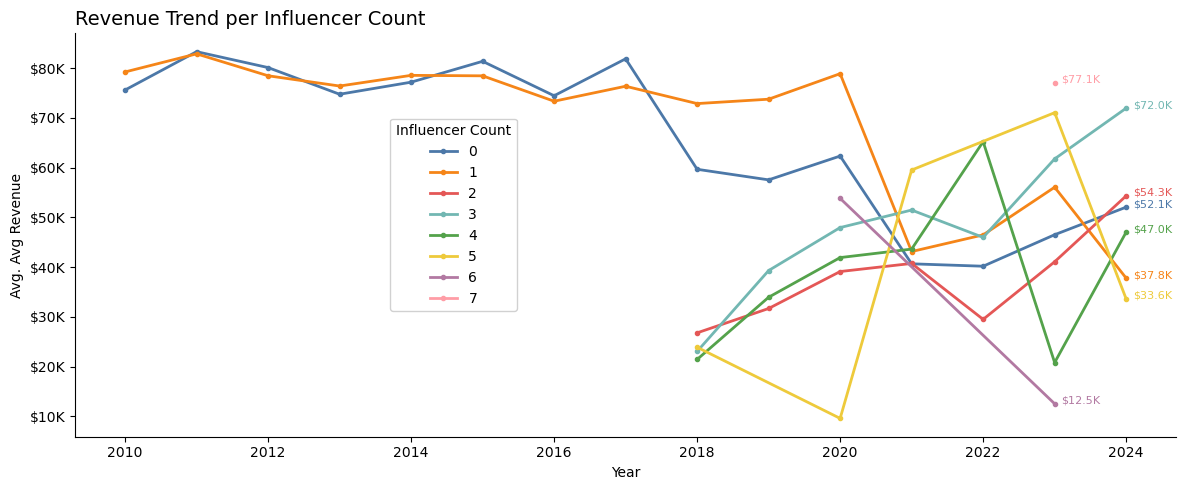

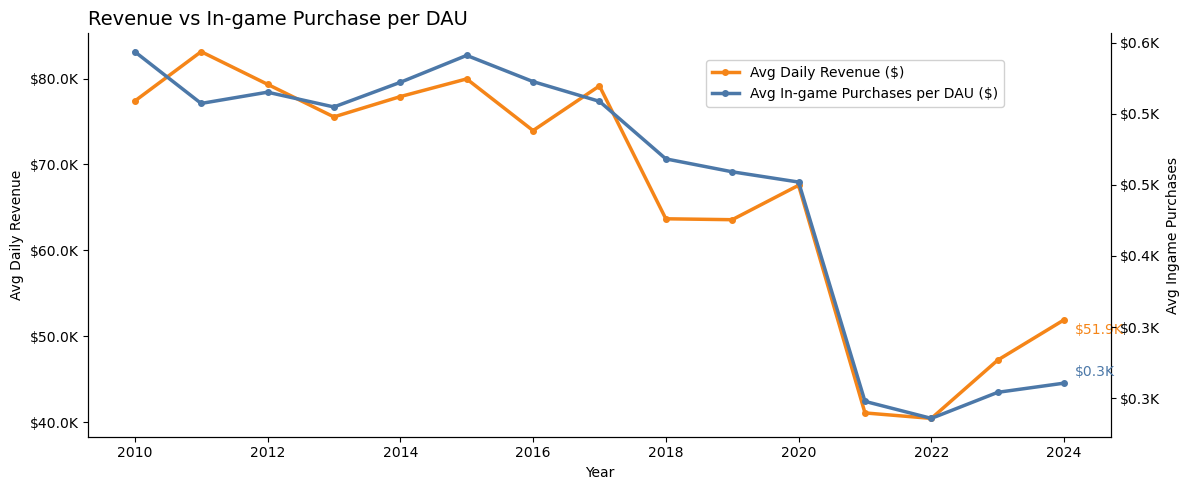

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm

# Load your cleaned data
df = pd.read_csv("gaming_data_cleaned.csv")
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year

# ── Chart 1: Revenue Trend per Influencer Count ─────────
influencer_yearly = df.groupby(["Year", "Influencer Endorsements"])["Revenue ($)"].mean().unstack()

# Color palette matching Tableau's default 8-color scheme
INFLUENCER_COLORS = {
    0: '#4C78A8', 1: '#F58518', 2: '#E45756', 3: '#72B7B2',
    4: '#54A24B', 5: '#EECA3B', 6: '#B279A2', 7: '#FF9DA6'
}

fig, ax = plt.subplots(figsize=(12, 5))
for count in sorted(influencer_yearly.columns):
    series = influencer_yearly[count].dropna()
    if len(series) == 0:
        continue
    ax.plot(series.index, series.values, label=str(count),
            color=INFLUENCER_COLORS.get(count, '#999999'), linewidth=2, marker='o', markersize=3)
    # Label the last available point for each line
    last_year = series.index[-1]
    last_val = series.values[-1]
    ax.annotate(f"${last_val/1e3:.1f}K", (last_year, last_val),
                xytext=(5, 0), textcoords='offset points', fontsize=8,
                color=INFLUENCER_COLORS.get(count, '#999999'))

ax.set_title("Revenue Trend per Influencer Count", fontsize=14, loc='left')
ax.set_xlabel("Year")
ax.set_ylabel("Avg. Avg Revenue")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
ax.legend(title="Influencer Count", loc='center left', bbox_to_anchor=(0.28, 0.55), framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("revenue_by_influencer_count.png", dpi=150)
plt.show()

# ── Chart 2: Revenue vs In-game Purchase per DAU (dual-axis) ──
yearly = df.groupby("Year").agg(
    Avg_Revenue=("Revenue ($)", "mean"),
    Avg_Purchases=("In-game Purchases ($)", "mean"),
    Avg_DAU=("Daily Active Users (DAU)", "mean")
).reset_index()

# Purchase per DAU = avg in-game purchases scaled per active user
yearly["Purchases_per_DAU"] = yearly["Avg_Purchases"] / yearly["Avg_DAU"] * 1000  # scaled for visibility

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(yearly["Year"], yearly["Avg_Revenue"], color='#F58518',
         linewidth=2.5, marker='o', markersize=4, label='Avg Daily Revenue ($)')
ax2.plot(yearly["Year"], yearly["Purchases_per_DAU"], color='#4C78A8',
         linewidth=2.5, marker='o', markersize=4, label='Avg In-game Purchases per DAU ($)')

# Label endpoints
last_year = yearly["Year"].iloc[-1]
last_rev = yearly["Avg_Revenue"].iloc[-1]
last_purch = yearly["Purchases_per_DAU"].iloc[-1]
ax1.annotate(f"${last_rev/1e3:.1f}K", (last_year, last_rev),
             xytext=(8, -10), textcoords='offset points', fontsize=10, color='#F58518')
ax2.annotate(f"${last_purch/1e3:.1f}K", (last_year, last_purch),
             xytext=(8, 5), textcoords='offset points', fontsize=10, color='#4C78A8')

ax1.set_title("Revenue vs In-game Purchase per DAU", fontsize=14, loc='left')
ax1.set_xlabel("Year")
ax1.set_ylabel("Avg Daily Revenue")
ax2.set_ylabel("Avg Ingame Purchases")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.1f}K"))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.1f}K"))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center',
           bbox_to_anchor=(0.75, 0.95), framealpha=0.9)

ax1.spines[['top']].set_visible(False)
ax2.spines[['top']].set_visible(False)
plt.tight_layout()
plt.savefig("revenue_vs_purchase_per_dau.png", dpi=150)
plt.show()

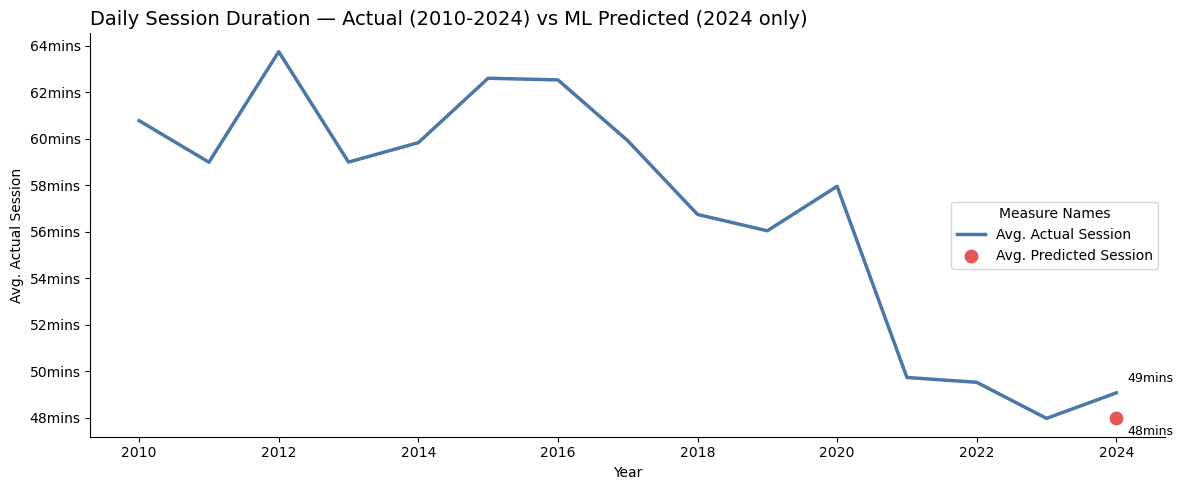

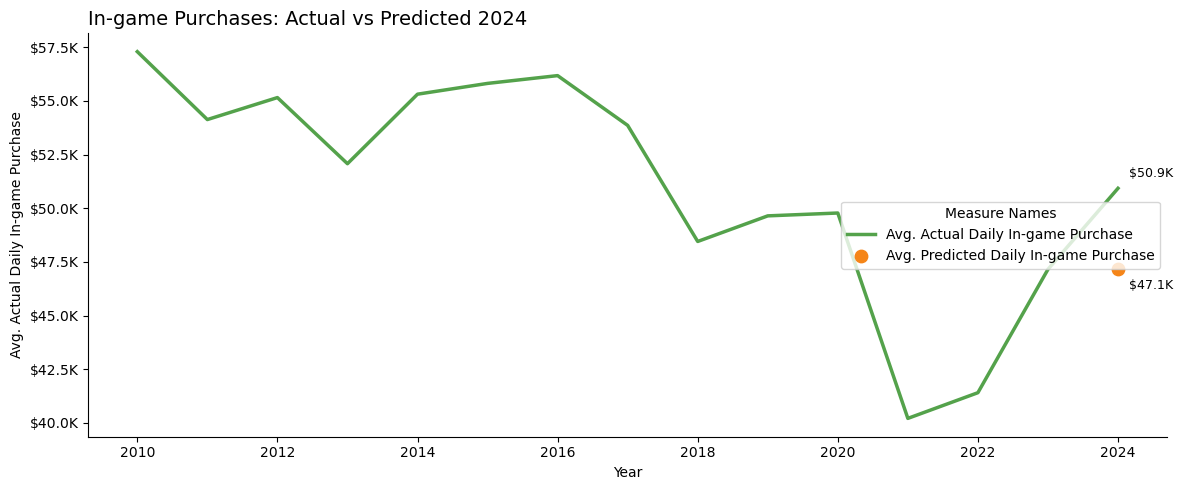

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

# Load your cleaned data
df = pd.read_csv("gaming_data_cleaned.csv")
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year

# Aggregate yearly averages
yearly = df.groupby("Year").agg(
    DAU=("Daily Active Users (DAU)", "mean"),
    Session_Duration=("Session Duration (minutes)", "mean"),
    Purchases=("In-game Purchases ($)", "mean"),
    Social_Mentions=("Social Media Mentions", "mean"),
    Revenue=("Revenue ($)", "mean")
).reset_index()

# ── Train/test split: train on 2010-2023, predict 2024 ──
features = ["DAU", "Social_Mentions", "Purchases"]  # predictors (excluding the target itself)
train = yearly[yearly["Year"] < 2024]
test = yearly[yearly["Year"] == 2024]

# ── Model 1: Predict Session Duration ──
X_train = train[["DAU", "Social_Mentions"]]
y_train_session = train["Session_Duration"]
X_test = test[["DAU", "Social_Mentions"]]

model_session = GradientBoostingRegressor(random_state=42)
model_session.fit(X_train, y_train_session)
predicted_session_2024 = model_session.predict(X_test)[0]
actual_session_2024 = test["Session_Duration"].values[0]

# ── Model 2: Predict In-game Purchases ──
y_train_purchases = train["Purchases"]
model_purchases = GradientBoostingRegressor(random_state=42)
model_purchases.fit(X_train, y_train_purchases)
predicted_purchases_2024 = model_purchases.predict(X_test)[0]
actual_purchases_2024 = test["Purchases"].values[0]

# ══════════════════════════════════════════════════════
# Chart 1: Daily Session Duration — Actual vs Predicted
# ══════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(yearly["Year"], yearly["Session_Duration"], color='#4C78A8',
        linewidth=2.5, label='Avg. Actual Session')
ax.scatter([2024], [predicted_session_2024], color='#E45756', s=80,
           zorder=5, label='Avg. Predicted Session')

# Labels
ax.annotate(f"{actual_session_2024:.0f}mins", (2024, actual_session_2024),
            xytext=(8, 8), textcoords='offset points', fontsize=9)
ax.annotate(f"{predicted_session_2024:.0f}mins", (2024, predicted_session_2024),
            xytext=(8, -12), textcoords='offset points', fontsize=9)

ax.set_title("Daily Session Duration — Actual (2010-2024) vs ML Predicted (2024 only)",
             fontsize=14, loc='left')
ax.set_xlabel("Year")
ax.set_ylabel("Avg. Actual Session")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}mins"))
ax.legend(title="Measure Names", loc='center right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("session_duration_actual_vs_predicted.png", dpi=150)
plt.show()

# ══════════════════════════════════════════════════════
# Chart 2: In-game Purchases — Actual vs Predicted 2024
# ══════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(yearly["Year"], yearly["Purchases"], color='#54A24B',
        linewidth=2.5, label='Avg. Actual Daily In-game Purchase')
ax.scatter([2024], [predicted_purchases_2024], color='#F58518', s=80,
           zorder=5, label='Avg. Predicted Daily In-game Purchase')

ax.annotate(f"${actual_purchases_2024/1e3:.1f}K", (2024, actual_purchases_2024),
            xytext=(8, 8), textcoords='offset points', fontsize=9)
ax.annotate(f"${predicted_purchases_2024/1e3:.1f}K", (2024, predicted_purchases_2024),
            xytext=(8, -14), textcoords='offset points', fontsize=9)

ax.set_title("In-game Purchases: Actual vs Predicted 2024", fontsize=14, loc='left')
ax.set_xlabel("Year")
ax.set_ylabel("Avg. Actual Daily In-game Purchase")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.1f}K"))
ax.legend(title="Measure Names", loc='center right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("purchases_actual_vs_predicted.png", dpi=150)
plt.show()

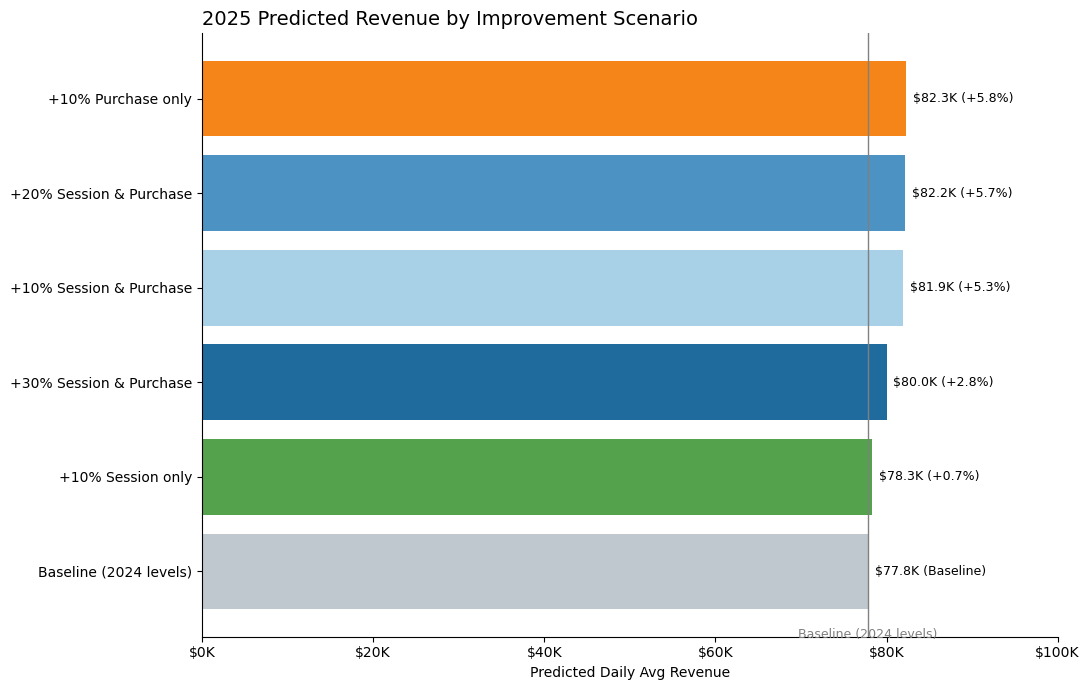

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Scenario results (from your 2025 prediction model) ──
scenarios = pd.DataFrame({
    "Scenario": ["+10% Purchase only", "+20% Session & Purchase",
                 "+10% Session & Purchase", "+30% Session & Purchase",
                 "+10% Session only", "Baseline (2024 levels)"],
    "Revenue": [82300, 82200, 81900, 80000, 78300, 77800],
    "Pct_Change": [5.8, 5.7, 5.3, 2.8, 0.7, 0.0]
})

SCENARIO_COLORS = {
    "+10% Purchase only": "#F58518",
    "+20% Session & Purchase": "#4C93C4",
    "+10% Session & Purchase": "#A8D0E6",
    "+30% Session & Purchase": "#1F6B9E",
    "+10% Session only": "#54A24B",
    "Baseline (2024 levels)": "#BFC8CF"
}

baseline = scenarios[scenarios["Scenario"] == "Baseline (2024 levels)"]["Revenue"].values[0]

fig, ax = plt.subplots(figsize=(11, 7))

# Plot bars in the same top-to-bottom order as the reference chart
plot_order = scenarios.iloc[::-1].reset_index(drop=True)  # reverse so highest is on top
bars = ax.barh(plot_order["Scenario"], plot_order["Revenue"],
               color=[SCENARIO_COLORS[s] for s in plot_order["Scenario"]])

# Value + percent labels at the end of each bar
for bar, revenue, pct, scenario in zip(bars, plot_order["Revenue"], plot_order["Pct_Change"], plot_order["Scenario"]):
    label = f"${revenue/1e3:.1f}K (Baseline)" if scenario == "Baseline (2024 levels)" else f"${revenue/1e3:.1f}K (+{pct:.1f}%)"
    ax.text(bar.get_width() + 800, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=9)

# Baseline reference line
ax.axvline(baseline, color='gray', linewidth=1)
ax.text(baseline, -0.7, "Baseline (2024 levels)", ha='center', fontsize=9, color='gray')

ax.set_title("2025 Predicted Revenue by Improvement Scenario", fontsize=14, loc='left')
ax.set_xlabel("Predicted Daily Avg Revenue")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K"))
ax.set_xlim(0, 100000)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig("2025_scenario_predictions.png", dpi=150)
plt.show()